In [1]:
import torch
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
rho = 1
mu = 1
u_in = 1
D = 1
L = 2

In [4]:
geom = dde.geometry.Rectangle(xmin=[-L/2, -D/2], xmax=[L/2, D/2])

In [7]:
def boundary_wall(X, on_boundary):
    print("X", X)
    print("on_boundary", on_boundary)

    on_wall = np.logical_and(np.logical_or(np.isclose(X[1], -D/2, rtol=1e-05, atol=1e-08), np.isclose(X[1],  D/2, rtol=1e-05, atol=1e-08)),on_boundary)
    return on_wall

def boundary_inlet(X, on_boundary):
    on_inlet = np.logical_and(np.isclose(X[0], -D/2, rtol=1e-05, atol=1e-08),on_boundary)
    return on_inlet

def boundary_outlet(X, on_boundary):
    on_outlet = np.logical_and(np.isclose(X[0], L/2, rtol=1e-05, atol=1e-08), on_boundary)
    return on_outlet

In [8]:
bc_wall_u = dde.DirichletBC(geom=geom, func=lambda X:0., on_boundary=boundary_wall, component=0)
bc_wall_v = dde.DirichletBC(geom=geom, func=lambda X:0., on_boundary=boundary_wall, component=1)

bc_inlet_u = dde.DirichletBC(geom=geom, func=lambda X:u_in, on_boundary=boundary_inlet, component=0)
bc_inlet_v = dde.DirichletBC(geom=geom, func=lambda X:0., on_boundary=boundary_inlet, component=1)

bc_outlet_p = dde.DirichletBC(geom=geom, func=lambda X:0., on_boundary=boundary_outlet, component=2)
bc_outlet_v = dde.DirichletBC(geom=geom, func=lambda X:0., on_boundary=boundary_outlet, component=1)

In [9]:
def pde(X, Y):
    du_x = dde.grad.jacobian(Y, X, i=0, j=0)
    du_y = dde.grad.jacobian(Y, X, i=0, j=1)
    dv_x = dde.grad.jacobian(Y, X, i=1, j=0)
    dv_y = dde.grad.jacobian(Y, X, i=1, j=1)
    dp_x = dde.grad.jacobian(Y, X, i=2, j=0)
    dp_y = dde.grad.jacobian(Y, X, i=2, j=1)

    du_xx = dde.grad.hessian(Y, X, component=0, i=0, j=0)
    du_yy = dde.grad.hessian(Y, X, component=0, i=1, j=1)
    dv_xx = dde.grad.hessian(Y, X, component=1, i=0, j=0)
    dv_yy = dde.grad.hessian(Y, X, component=1, i=1, j=1)

    pde_u = Y[:,0:1] * du_x + Y[:, 1:2] * du_y + 1/rho * dp_x - (mu/rho) * (du_xx + du_yy)
    pde_v = Y[:,0:1] * dv_x + Y[:, 1:2] * dv_y + 1/rho * dp_y - (mu/rho) * (dv_xx + dv_yy)
    pde_cont = du_x + dv_y

    return [pde_u, pde_v, pde_cont]

In [10]:
data = dde.data.PDE(geom, pde, [bc_wall_u, bc_wall_v, bc_inlet_u, bc_inlet_u],num_domain=2000, num_boundary=2000, num_test=200)

X [1.  0.5]
on_boundary True
X [ 0.5 -0.5]
on_boundary True
X [-0.5  0.5]
on_boundary True
X [-0.25 -0.5 ]
on_boundary True
X [0.25 0.5 ]
on_boundary True
X [ 1.   -0.25]
on_boundary True
X [-1.    0.25]
on_boundary True
X [-0.625 -0.5  ]
on_boundary True
X [0.625 0.5  ]
on_boundary True
X [ 0.875 -0.5  ]
on_boundary True
X [-0.875  0.5  ]
on_boundary True
X [ 0.125 -0.5  ]
on_boundary True
X [-0.125  0.5  ]
on_boundary True
X [1.    0.125]
on_boundary True
X [-1.    -0.125]
on_boundary True
X [-0.8125 -0.5   ]
on_boundary True
X [0.8125 0.5   ]
on_boundary True
X [ 0.6875 -0.5   ]
on_boundary True
X [-0.6875  0.5   ]
on_boundary True
X [-0.0625 -0.5   ]
on_boundary True
X [0.0625 0.5   ]
on_boundary True
X [ 1.     -0.0625]
on_boundary True
X [-1.      0.0625]
on_boundary True
X [-0.4375 -0.5   ]
on_boundary True
X [0.4375 0.5   ]
on_boundary True
X [ 1.     -0.4375]
on_boundary True
X [-1.      0.4375]
on_boundary True
X [ 0.3125 -0.5   ]
on_boundary True
X [-0.3125  0.5   ]
on_bound

Text(0, 0.5, 'y')

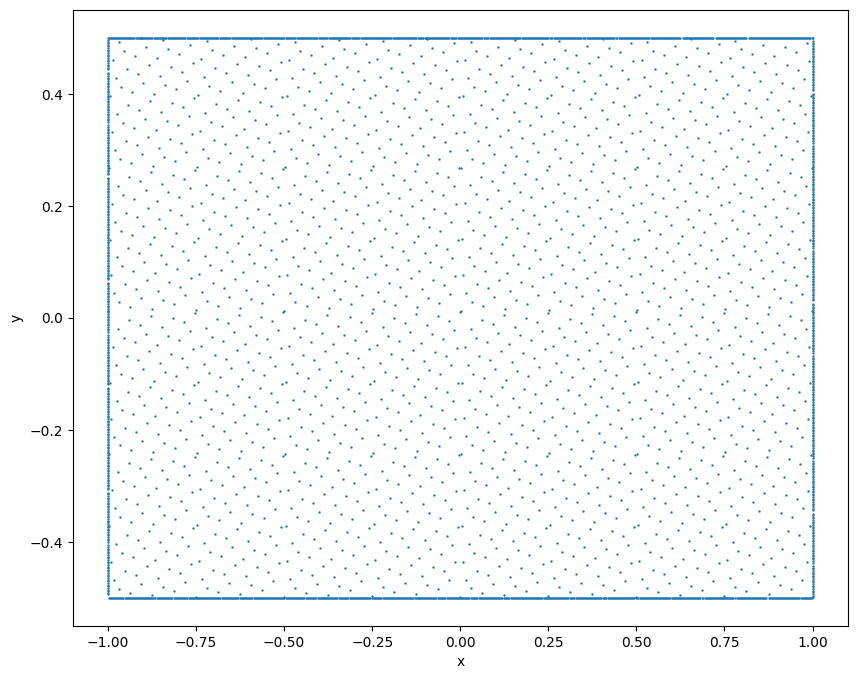

In [11]:
plt.figure(figsize=(10,8))
plt.scatter(data.train_x_all[:,0], data.train_x_all[:,1], s=0.5)
plt.xlabel("x")
plt.ylabel("y")

In [15]:
net = dde.maps.FNN([2] + [64] * 5 + [3], "tanh", "Glorot uniform")

In [17]:
model = dde.Model(data, net)
model.compile("adam", lr=1e-3)


Compiling model...
'compile' took 1.279525 s



In [18]:
loss_history, train_state = model.train(epochs=10000)

Training model...

Step      Train loss                                                                Test loss                                                                 Test metric
0         [1.16e-02, 3.35e-02, 3.03e-03, 4.67e-03, 1.04e-02, 1.12e+00, 1.12e+00]    [9.98e-03, 3.52e-02, 2.40e-03, 4.67e-03, 1.04e-02, 1.12e+00, 1.12e+00]    []  
1000      [5.75e-03, 1.10e-02, 7.10e-03, 1.34e-01, 1.16e-02, 5.84e-03, 5.84e-03]    [4.73e-03, 7.93e-03, 4.61e-03, 1.34e-01, 1.16e-02, 5.84e-03, 5.84e-03]    []  
2000      [3.75e-03, 1.11e-02, 3.00e-03, 8.30e-02, 1.20e-02, 3.10e-03, 3.10e-03]    [2.31e-03, 4.22e-03, 9.78e-04, 8.30e-02, 1.20e-02, 3.10e-03, 3.10e-03]    []  
3000      [1.48e-03, 1.40e-03, 2.42e-03, 7.16e-02, 1.22e-02, 2.46e-03, 2.46e-03]    [9.49e-04, 1.04e-03, 1.23e-03, 7.16e-02, 1.22e-02, 2.46e-03, 2.46e-03]    []  
4000      [4.42e-03, 6.07e-03, 2.48e-03, 6.62e-02, 1.18e-02, 2.00e-03, 2.00e-03]    [2.51e-03, 1.79e-03, 1.06e-03, 6.62e-02, 1.18e-02, 2.00e-03, 2.00e-03]    [

In [21]:
dde.optimizers.config.set_LBFGS_options(maxiter=3000)
model.compile("L-BFGS")
loss_history, train_state = model.train()
dde.saveplot(loss_history=loss_history, train_state=train_state, isplot=False)

Compiling model...
'compile' took 0.001045 s

Training model...

Step      Train loss                                                                Test loss                                                                 Test metric
10000     [9.05e-04, 1.16e-03, 1.37e-03, 5.63e-02, 1.03e-02, 1.47e-03, 1.47e-03]    [5.90e-04, 5.33e-04, 8.02e-04, 5.63e-02, 1.03e-02, 1.47e-03, 1.47e-03]    []  
11000     [2.21e-03, 1.93e-03, 8.15e-04, 2.23e-02, 7.95e-03, 3.35e-04, 3.35e-04]    [2.28e-03, 4.10e-03, 5.54e-04, 2.23e-02, 7.95e-03, 3.35e-04, 3.35e-04]    []  
12000     [1.71e-03, 1.50e-03, 6.60e-04, 1.49e-02, 6.89e-03, 1.50e-04, 1.50e-04]    [2.61e-03, 2.79e-03, 5.74e-04, 1.49e-02, 6.89e-03, 1.50e-04, 1.50e-04]    []  
13000     [1.22e-03, 1.49e-03, 4.59e-04, 1.24e-02, 6.04e-03, 1.24e-04, 1.24e-04]    [2.19e-03, 1.73e-03, 4.63e-04, 1.24e-02, 6.04e-03, 1.24e-04, 1.24e-04]    []  

Best model at step 13000:
  train loss: 2.18e-02
  test loss: 2.30e-02
  test metric: []

'train' took 230.07131

In [26]:
samples = geom.random_points(50000)
result  = model.predict(samples)

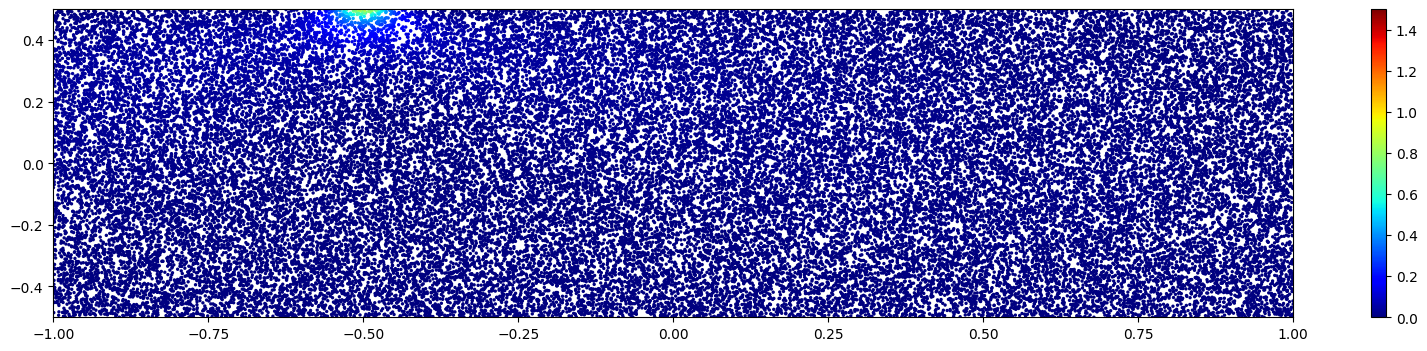

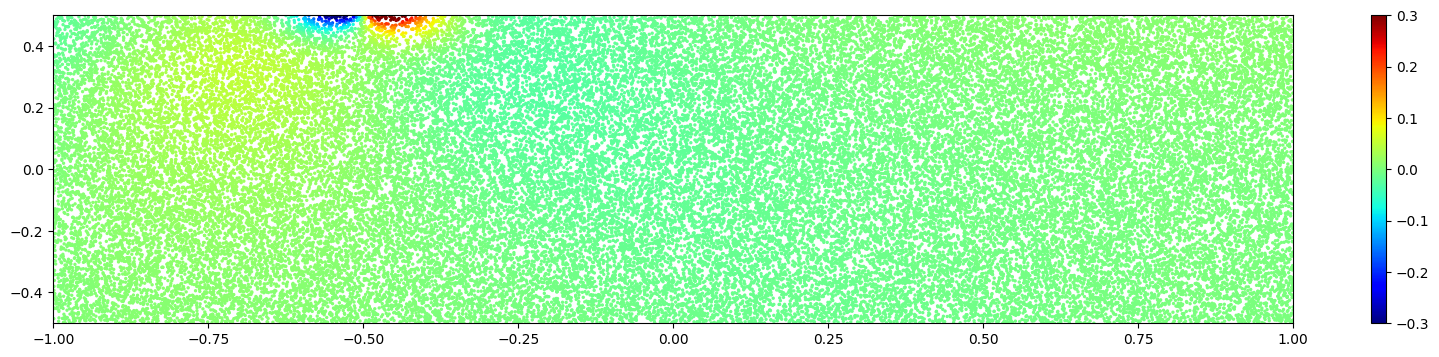

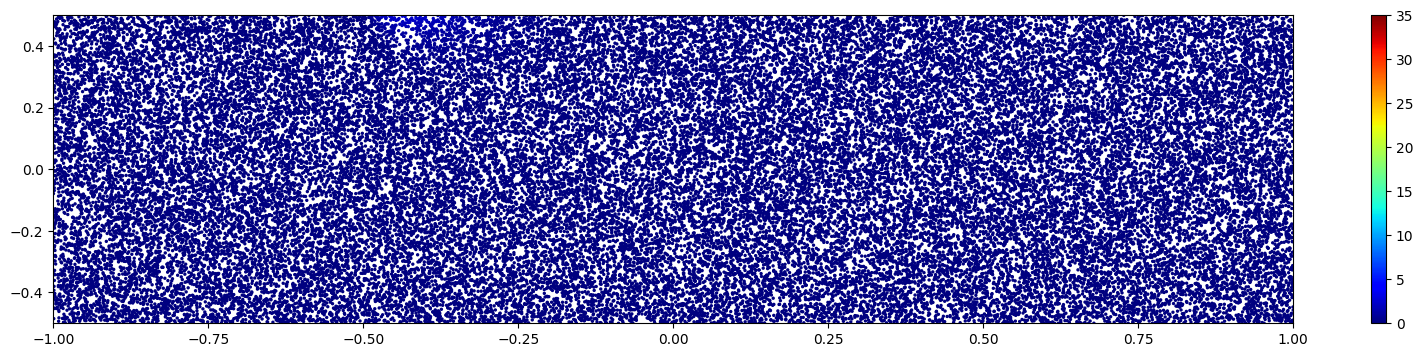

In [27]:
color_legend = [[0, 1.5], [-0.3, 0.3], [0, 35]]

for idx in range(3):
    plt.figure(figsize=(20,4))
    plt.scatter(samples[:,0], samples[:,1], c = result[:,idx], cmap='jet', s=2)
    plt.colorbar()
    plt.clim(color_legend[idx])
    plt.xlim((0-L/2, L-L/2))
    plt.ylim((0-D/2, D-D/2))